# Exploratory Data Analysis of Arvoredo Dataset

Exploring Lisbon's open dataset Arvoredo.

In [18]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import folium

In [3]:
# load the CSV file into a DataFrame
csv_path = "../data/raw/Ambiente_DMEVAE_3124658027004115814.csv"
df = pd.read_csv(csv_path)
df.head()

,Código SIG Novo,Código SIG,Morada,Espécie,PAP,Manutenção,Ocupação,Local,Tipologia,Freguesia,Nome Vulgar,GESP_C_PK,GlobalID,x,y
0,1,330352827082,Alameda dos Oceanos,Quercus robur,NaN,JF,Árvore,Via pública,Caldeira,Parque das Nações,carvalho-roble;carvalho-alvarinho,62234,cb3fb32b-8691-48b4-b139-806677c209ee,-1.012476e+06,4.689424e+06
1,2,330352827083,Alameda dos Oceanos,Quercus robur,NaN,JF,Árvore,Via pública,Caldeira,Parque das Nações,carvalho-roble;carvalho-alvarinho,62235,4816ed5f-4730-46ca-8a0c-ecb5ef6cf027,-1.012475e+06,4.689433e+06
2,3,330352826040,Alameda dos Oceanos,Quercus robur,NaN,JF,Árvore,Via pública,Caldeira,Parque das Nações,carvalho-roble;carvalho-alvarinho,62236,9a6c58af-0225-4fb5-949a-144175eedec1,-1.012471e+06,4.689406e+06
3,4,330352826041,Alameda dos Oceanos,Quercus robur,NaN,JF,Árvore,Via pública,Caldeira,Parque das Nações,carvalho-roble;carvalho-alvarinho,62237,23176d79-58b4-4d1b-bcfb-d3b3215a3706,-1.012470e+06,4.689415e+06
4,5,330352826042,Alameda dos Oceanos,Quercus robur,NaN,JF,Árvore,Via pública,Caldeira,Parque das Nações,carvalho-roble;carvalho-alvarinho,62238,8e1155ae-1951-401c-8801-d6f110ac7c6b,-1.012469e+06,4.689424e+06


In [4]:
# check dataset shape and info
print(f"Dataset shape: {df.shape}")
print("\nDataset info:")
print(df.info())

# check for missing data
print("\nMissing data:")
print(df.isnull().sum())

Dataset shape: (78201, 15)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 78201 entries, 0 to 78200
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Código SIG Novo  78201 non-null  int64  
 1   Código SIG       57314 non-null  str    
 2   Morada           78027 non-null  str    
 3   Espécie          78201 non-null  str    
 4   PAP              63285 non-null  str    
 5   Manutenção       72795 non-null  str    
 6   Ocupação         73796 non-null  str    
 7   Local            75066 non-null  str    
 8   Tipologia        65736 non-null  str    
 9   Freguesia        78200 non-null  str    
 10  Nome Vulgar      78023 non-null  str    
 11  GESP_C_PK        78201 non-null  int64  
 12  GlobalID         78201 non-null  str    
 13  x                78201 non-null  float64
 14  y                78201 non-null  float64
dtypes: float64(2), int64(2), str(11)
memory usage: 8.9 MB
None

Missing data:

In [5]:
# remove specified columns if they exist
df.drop(columns=['Código SIG', 'GESP_C_PK', 'GlobalID'], errors='ignore', inplace=True)
df.head()

,Código SIG Novo,Morada,Espécie,PAP,Manutenção,Ocupação,Local,Tipologia,Freguesia,Nome Vulgar,x,y
0,1,Alameda dos Oceanos,Quercus robur,NaN,JF,Árvore,Via pública,Caldeira,Parque das Nações,carvalho-roble;carvalho-alvarinho,-1.012476e+06,4.689424e+06
1,2,Alameda dos Oceanos,Quercus robur,NaN,JF,Árvore,Via pública,Caldeira,Parque das Nações,carvalho-roble;carvalho-alvarinho,-1.012475e+06,4.689433e+06
2,3,Alameda dos Oceanos,Quercus robur,NaN,JF,Árvore,Via pública,Caldeira,Parque das Nações,carvalho-roble;carvalho-alvarinho,-1.012471e+06,4.689406e+06
3,4,Alameda dos Oceanos,Quercus robur,NaN,JF,Árvore,Via pública,Caldeira,Parque das Nações,carvalho-roble;carvalho-alvarinho,-1.012470e+06,4.689415e+06
4,5,Alameda dos Oceanos,Quercus robur,NaN,JF,Árvore,Via pública,Caldeira,Parque das Nações,carvalho-roble;carvalho-alvarinho,-1.012469e+06,4.689424e+06


/tmp/ipykernel_9430/228955750.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


Morada: 2645 unique categories (including missing)
Morada
Não identificada                2700
Alameda dos Oceanos             1748
Alameda Cardeal Cerejeira       1541
Campo Grande                    1196
Eixo Central                    1165
Avenida da Liberdade            1009
Rua 19                          1002
Avenida Infante Dom Henrique     721
Avenida Dom João II              706
Rua Marquês de Fronteira         533
Name: count, dtype: int64
------------------------------------------------------------
Espécie: 458 unique categories (including missing)
Espécie
Celtis australis          9874
Não identificada          8541
Jacaranda mimosifolia     4167
Platanus x hybrida        3046
Cupressus sempervirens    2171
Cercis siliquastrum       1954
Tipuana tipu              1938
Tilia sp.                 1799
Pinus pinea               1733
Fraxinus angustifolia     1511
Name: count, dtype: int64
------------------------------------------------------------
PAP: 574 unique categories (i

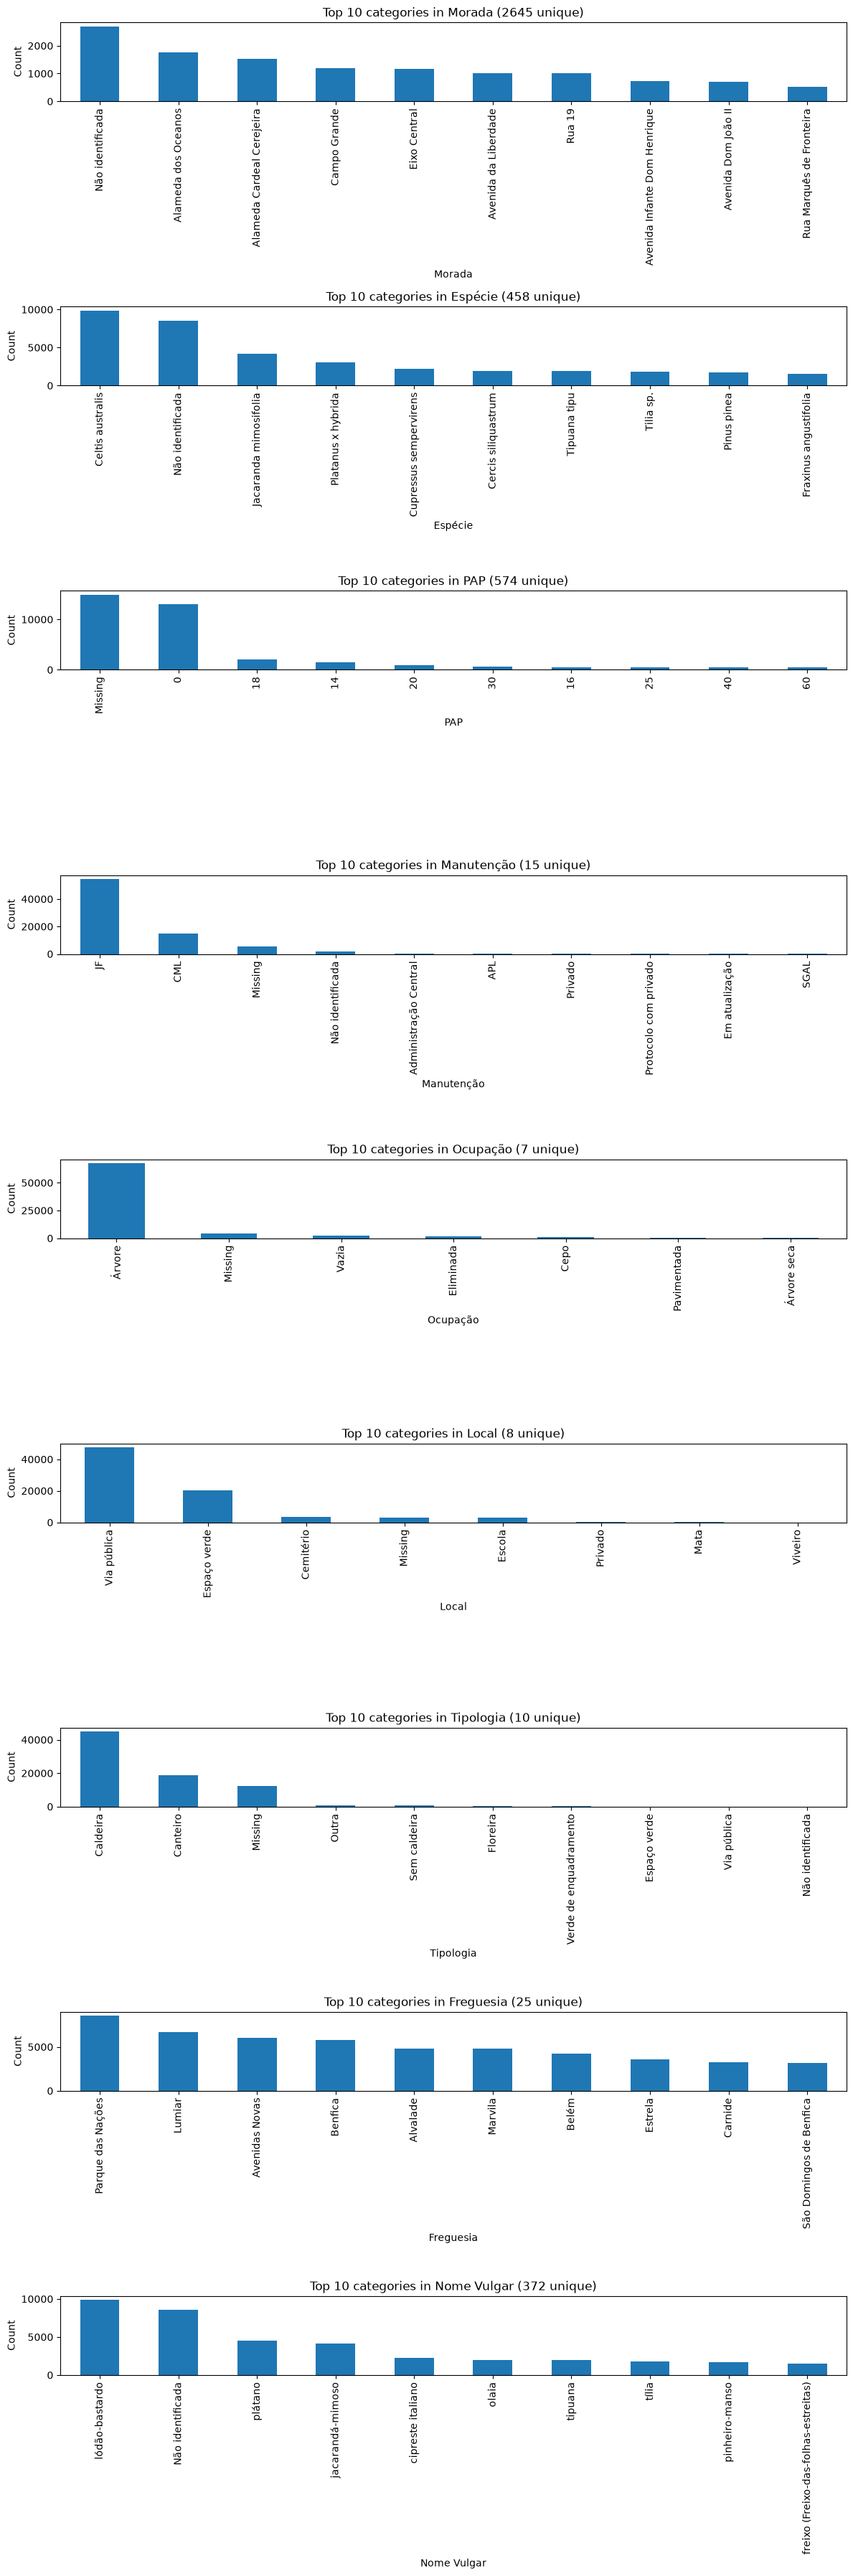

In [6]:
# plot categorical data
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    unique_count = df[col].nunique(dropna=False)
    print(f"{col}: {unique_count} unique categories (including missing)")
    print(df[col].fillna("Missing").value_counts().head(10))
    print("-" * 60)

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(12, 4 * len(cat_cols)))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    vc = df[col].fillna("Missing").value_counts().head(10)
    vc.plot(kind="bar", ax=ax)
    ax.set_title(f"Top 10 categories in {col} ({df[col].nunique(dropna=False)} unique)")
    ax.set_ylabel("Count")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

                 Missing Count  Missing Percentage
Código SIG Novo              0                0.00
Morada                     174                0.22
Espécie                      0                0.00
PAP                      14916               19.07
Manutenção                5406                6.91
Ocupação                  4405                5.63
Local                     3135                4.01
Tipologia                12465               15.94
Freguesia                    1                0.00
Nome Vulgar                178                0.23
x                            0                0.00
y                            0                0.00


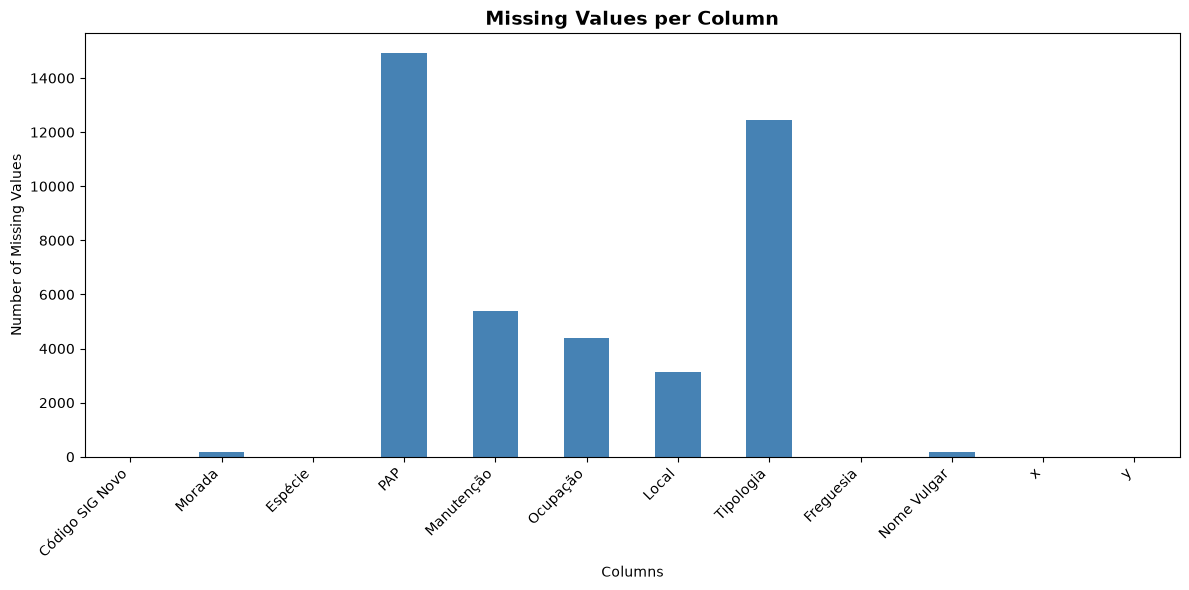

In [7]:
# calculate missing data count and percentage for each column
missing_data = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

print(missing_data)

# create a bar plot
fig, ax = plt.subplots(figsize=(12, 6))
missing_data['Missing Count'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Missing Values per Column', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Missing Values')
ax.set_xlabel('Columns')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
# define columns to analyze
columns_to_analyze = ['Espécie', 'Manutenção', 'Ocupação', 'Local', 'Tipologia', 'Nome Vulgar']

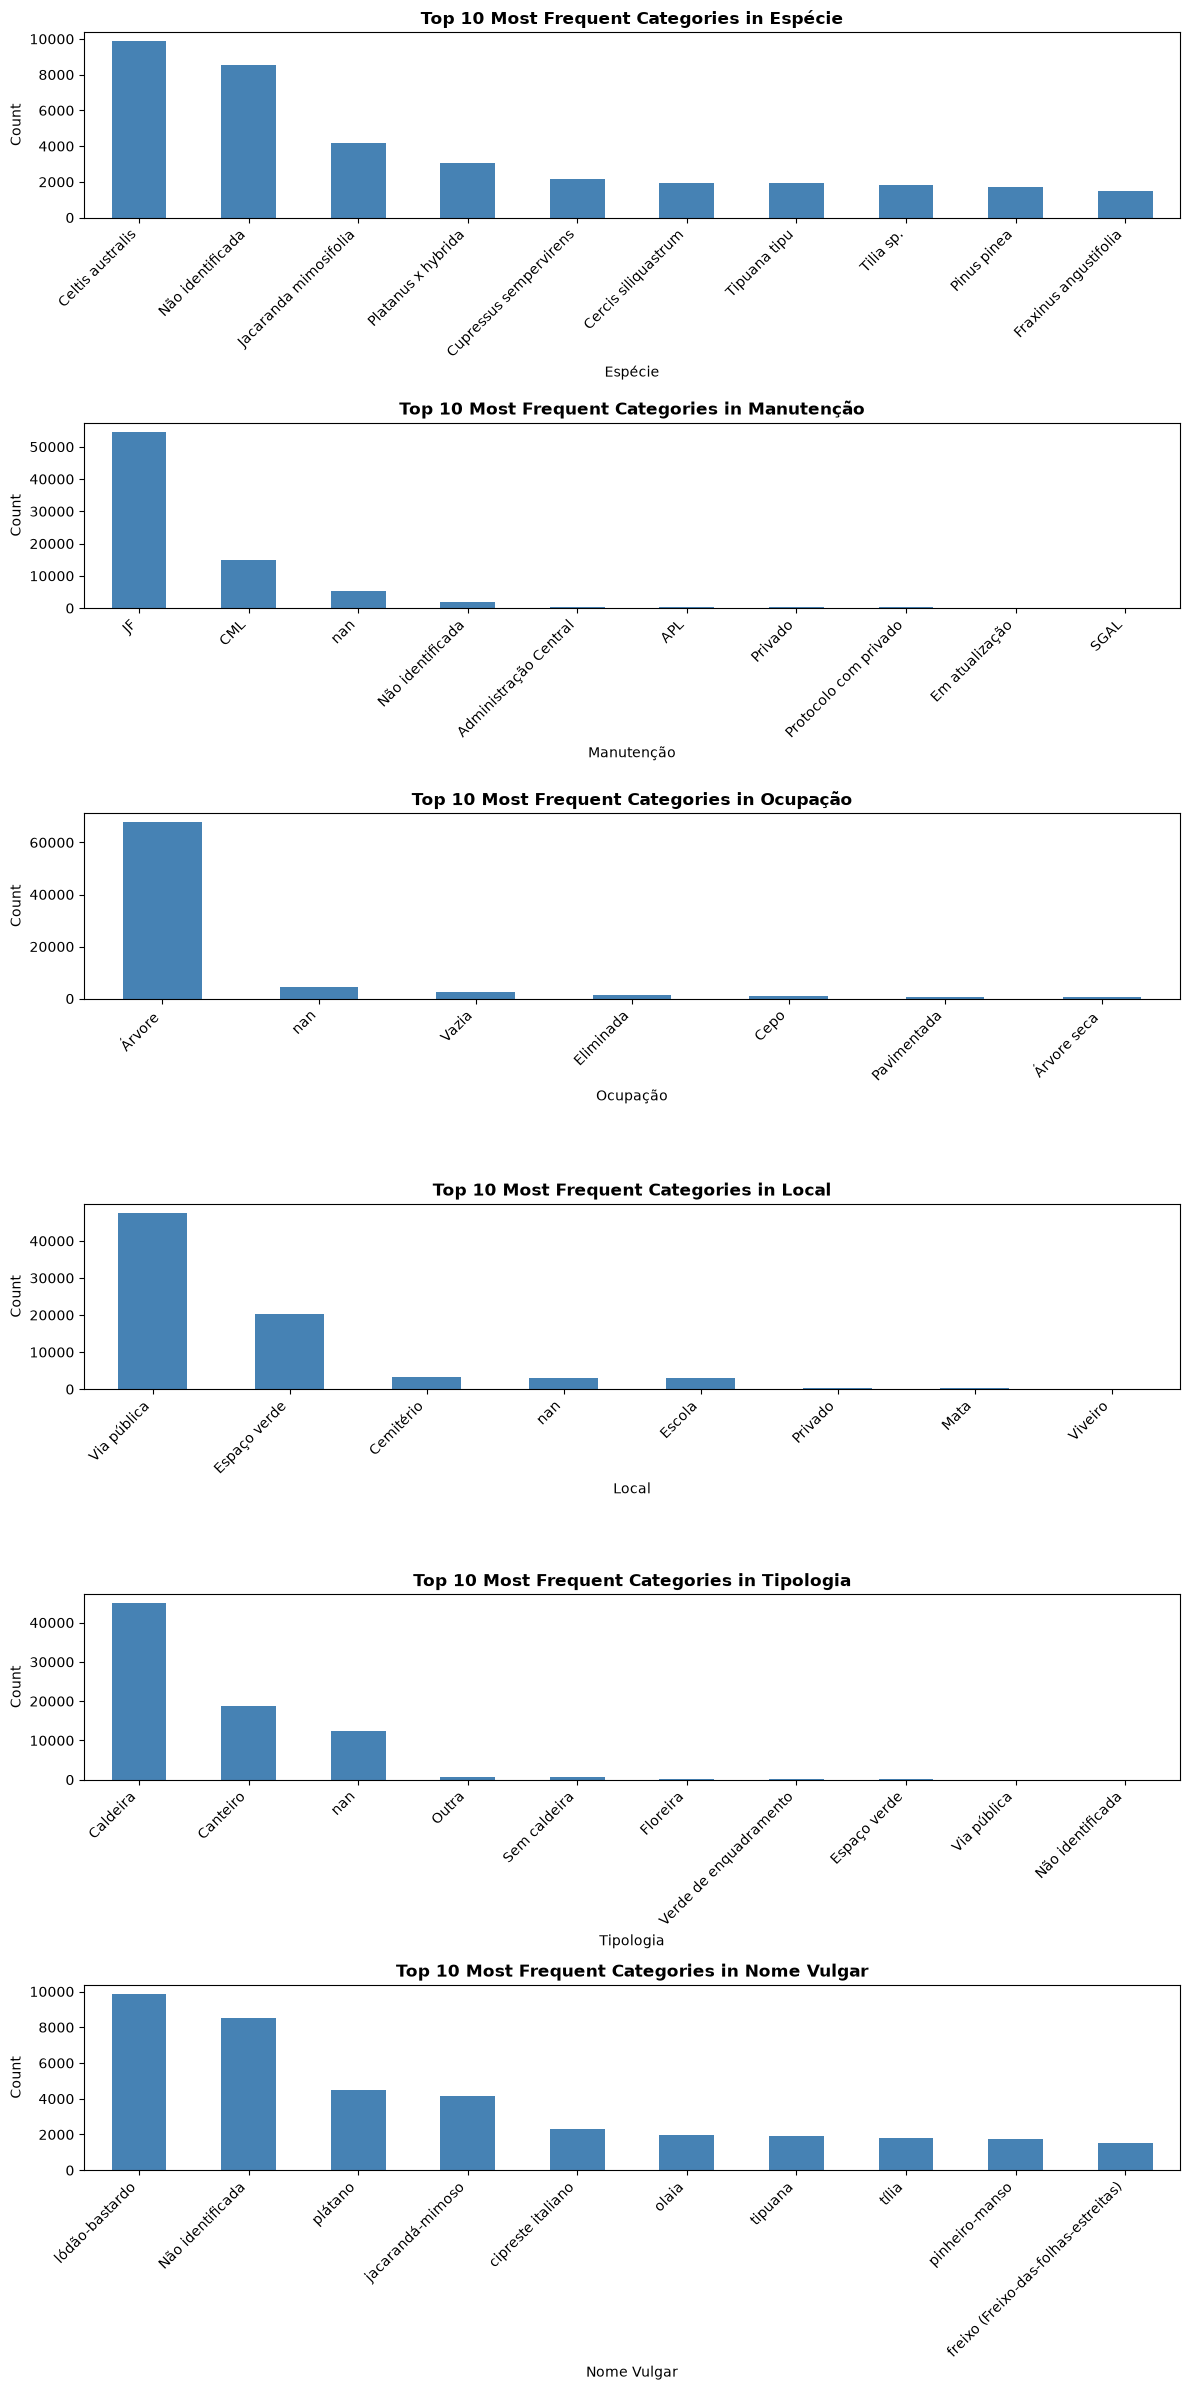

In [9]:
# create plots for top 10 most frequent categories for each column
fig, axes = plt.subplots(len(columns_to_analyze), 1, figsize=(12, 4 * len(columns_to_analyze)))

for ax, col in zip(axes, columns_to_analyze):
    top_10 = df[col].value_counts(dropna=False).head(10)
    top_10.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f"Top 10 Most Frequent Categories in {col}", fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xlabel(col)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [10]:
# saved cleaned dataset to a new CSV file
df.to_csv('../data/arvoredo_cleaned.csv', index=False)
print("Dataset saved to 'arvoredo_cleaned.csv'")

Dataset saved to 'arvoredo_cleaned.csv'


In [12]:
# convert and add coordinates from EPSG:3857 to EPSG:4326
from pyproj import Transformer

transformer = Transformer.from_crs(
    "EPSG:3857",
    "EPSG:4326",
    always_xy=True
)

df["longitude"], df["latitude"] = zip(
    *df.apply(
        lambda r: transformer.transform(r["x"], r["y"]),
        axis=1
    )
)

In [13]:
# remove old coordinate columns
df.drop(columns=['x', 'y'], inplace=True, errors='ignore')
df.head()

,Código SIG Novo,Morada,Espécie,PAP,Manutenção,Ocupação,Local,Tipologia,Freguesia,Nome Vulgar,longitude,latitude
0,1,Alameda dos Oceanos,Quercus robur,NaN,JF,Árvore,Via pública,Caldeira,Parque das Nações,carvalho-roble;carvalho-alvarinho,-9.095224,38.774517
1,2,Alameda dos Oceanos,Quercus robur,NaN,JF,Árvore,Via pública,Caldeira,Parque das Nações,carvalho-roble;carvalho-alvarinho,-9.095219,38.774579
2,3,Alameda dos Oceanos,Quercus robur,NaN,JF,Árvore,Via pública,Caldeira,Parque das Nações,carvalho-roble;carvalho-alvarinho,-9.095178,38.774387
3,4,Alameda dos Oceanos,Quercus robur,NaN,JF,Árvore,Via pública,Caldeira,Parque das Nações,carvalho-roble;carvalho-alvarinho,-9.095173,38.774452
4,5,Alameda dos Oceanos,Quercus robur,NaN,JF,Árvore,Via pública,Caldeira,Parque das Nações,carvalho-roble;carvalho-alvarinho,-9.095168,38.774515


In [14]:
# subsample the dataframe to 1000 points for lighter analysis/export (for testing purposes)
# df_sample = df.sample(n=1000, random_state=42).reset_index(drop=True)
# print(f"Sampled dataframe shape: {df_sample.shape}")
# df_sample.to_csv("../data/arvoredo_datawrapper_sample1000.csv", index=False)

In [15]:
# locate trees in schools
df_escolas = df[df["Local"].fillna("").str.lower() == "escola"]
print(f"Filtered dataframe shape: {df_escolas.shape}")
df_escolas.head()

Filtered dataframe shape: (3092, 12)


,Código SIG Novo,Morada,Espécie,PAP,Manutenção,Ocupação,Local,Tipologia,Freguesia,Nome Vulgar,longitude,latitude
1491,1663,Rua Aquilino Ribeiro,Fraxinus angustifolia,90,JF,Árvore,Escola,Canteiro,Marvila,freixo (Freixo-das-folhas-estreitas),-9.117506,38.753310
1492,1664,Rua Aquilino Ribeiro,Fraxinus sp.,104,JF,Árvore,Escola,Canteiro,Marvila,freixo,-9.117489,38.753375
1493,1665,Rua Aquilino Ribeiro,Schinus molle,180,JF,Árvore,Escola,Canteiro,Marvila,pimenteiro-bastardo,-9.117550,38.753302
1494,1666,Rua Aquilino Ribeiro,Fraxinus sp.,53,JF,Árvore,Escola,Canteiro,Marvila,freixo,-9.117570,38.753298
1495,1667,Rua Aquilino Ribeiro,Prunus cerasifera subsp. pissardii,28,JF,Árvore,Escola,Canteiro,Marvila,abrunheiro-dos-jardins,-9.117604,38.753315


In [16]:
# save trees in schools to a new CSV file
df_escolas.to_csv("../data/arvoredo_escolas.csv", index=False)

In [26]:
from folium.plugins import FastMarkerCluster

map_center = [df["latitude"].mean(), df["longitude"].mean()]
m = folium.Map(location=map_center, zoom_start=12, tiles="CartoDB positron")

coords = df.loc[
    df["latitude"].notna() & df["longitude"].notna(),
    ["latitude", "longitude"]
].values.tolist()

FastMarkerCluster(coords).add_to(m)


In [ ]:
# update the map with leaf icons for all trees
m = folium.Map(location=map_center, zoom_start=12, tiles="CartoDB positron")

for idx, row in df.iterrows():
    if pd.notna(row["latitude"]) and pd.notna(row["longitude"]):
        folium.Marker(
            location=[row["latitude"], row["longitude"]],
            popup=f"{row['Nome Vulgar']} - {row['Espécie']}",
            icon=folium.Icon(icon="leaf", prefix="fa", color="green")
        ).add_to(m)

In [29]:
# create a map with tree icons for schools
map_center = [df_escolas["latitude"].mean(), df_escolas["longitude"].mean()]
map_escolas = folium.Map(location=map_center, zoom_start=12, tiles="CartoDB positron")

# add individual markers with tree icons
for idx, row in df_escolas.iterrows():
    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        popup=f"{row['Nome Vulgar']} - {row['Espécie']}",
        icon=folium.Icon(icon="leaf", prefix="fa", color="green")
    ).add_to(map_escolas)

map_escolas.save('../data/escolas_map.html')
print("Map saved to '../data/escolas_map.html'")

Map saved to '../data/escolas_map.html'


In [28]:
m.save('../data/arvoredo_map.html')
print("Map saved to '../data/arvoredo_map.html'")

Map saved to '../data/arvoredo_map.html'
